**Problem Statement**

This project analyzes e-commerce sales data to understand the factors affecting profitability and to predict whether an order will generate profit or loss.

Businesses often offer discounts to increase sales, but excessive discounts may reduce profitability. This project uses machine learning to predict the profit status of an order based on factors such as sales amount, discount, quantity, shipping cost, and product category.

The insights from this analysis can help businesses optimize discount strategies and improve overall profitability.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("superstore.csv", encoding='latin1')

df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [4]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True)

In [5]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [6]:
df.describe()

,order_date,ship_date,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528,3.476545,0.142908,28.641740,26.375915,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,2.278766,0.212280,174.424113,57.296804,1.098931


In [7]:
df['shipping_days'] = (df['ship_date'] - df['order_date']).dt.days

In [8]:
df['order_month'] = df['order_date'].dt.month
df['order_year'] = df['order_date'].dt.year

In [9]:
df['profit_status'] = df['profit'].apply(lambda x: 1 if x > 0 else 0)

In [14]:
# Convert numeric columns to proper numeric format
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['shipping_cost'] = pd.to_numeric(df['shipping_cost'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

In [15]:
df = df.dropna()

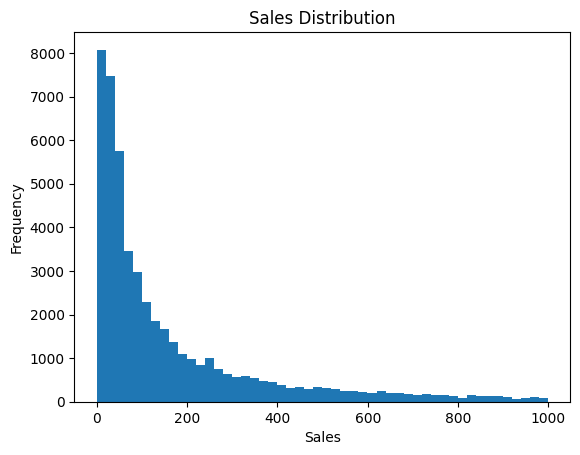

In [16]:
plt.hist(df['sales'], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

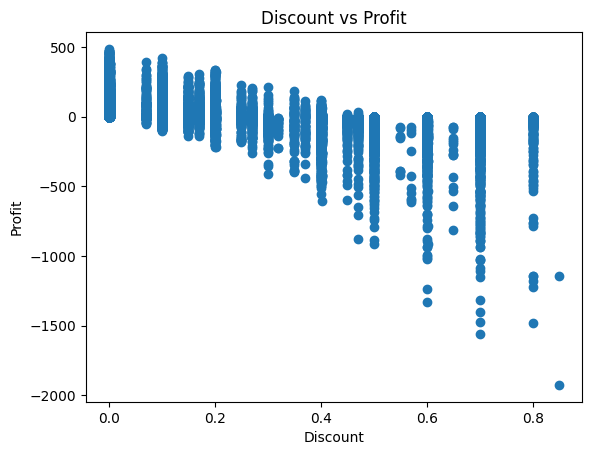

In [17]:
plt.scatter(df['discount'], df['profit'])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

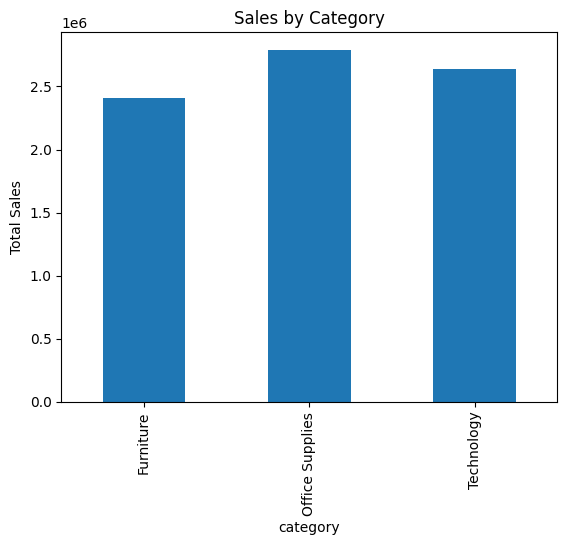

In [18]:
df.groupby('category')['sales'].sum().plot(kind='bar')

plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.show()

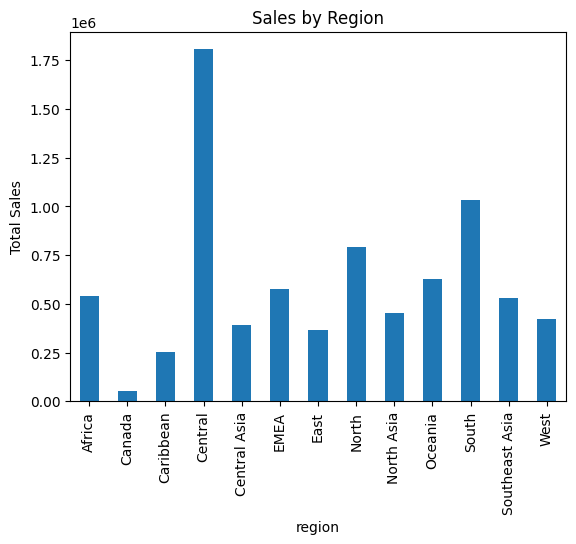

In [19]:
df.groupby('region')['sales'].sum().plot(kind='bar')

plt.title("Sales by Region")
plt.ylabel("Total Sales")
plt.show()

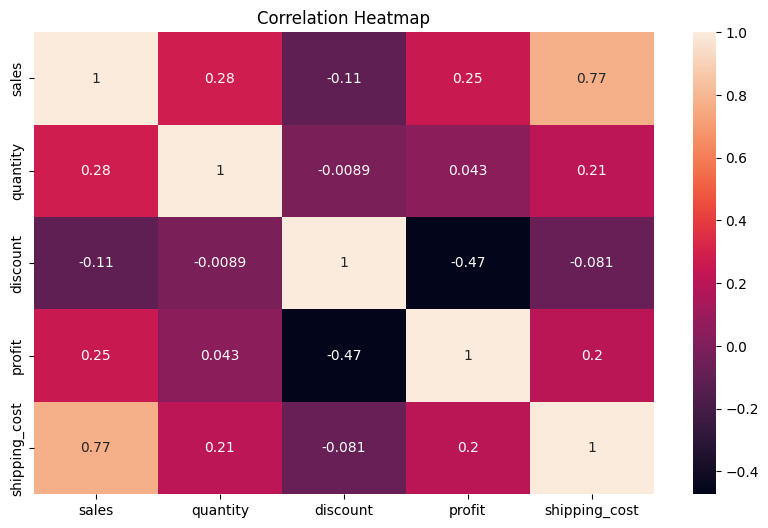

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(df[['sales','quantity','discount','profit','shipping_cost']].corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
le = LabelEncoder()

categorical_cols = [
    'category',
    'sub_category',
    'region',
    'segment',
    'ship_mode',
    'order_priority'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [22]:
features = [
    'sales',
    'quantity',
    'discount',
    'shipping_cost',
    'shipping_days',
    'category',
    'sub_category',
    'region',
    'segment',
    'ship_mode'
]

X = df[features]

y = df['profit_status']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9211878339498561


In [25]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8811138512124949


In [26]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9193382655158241


In [32]:
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

Logistic Regression Accuracy: 0.9211878339498561
Decision Tree Accuracy: 0.8811138512124949
Random Forest Accuracy: 0.9193382655158241


In [33]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})

results

,Model,Accuracy
0,Logistic Regression,0.921188
1,Decision Tree,0.881114
2,Random Forest,0.919338


In [28]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      2547
           1       0.93      0.96      0.95      7185

    accuracy                           0.92      9732
   macro avg       0.91      0.88      0.89      9732
weighted avg       0.92      0.92      0.92      9732



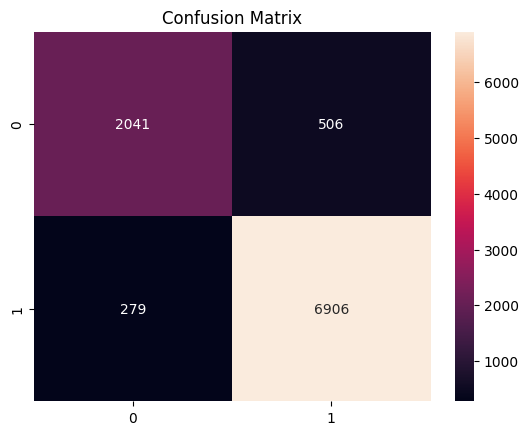

In [29]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.show()

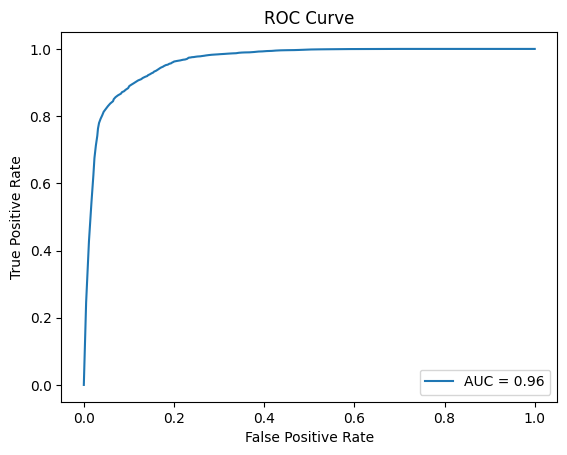

In [30]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

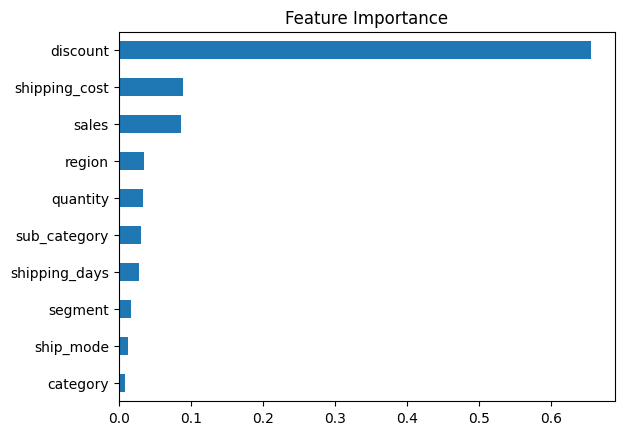

In [31]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")

plt.show()

In [34]:
profit_discount = df[df['discount'] > 0]['profit'].mean()

print("Average Profit with Discount:", profit_discount)

Average Profit with Discount: -16.956536273692194


In [35]:
profit_no_discount = df[df['discount'] == 0]['profit'].mean()

print("Average Profit without Discount:", profit_no_discount)

Average Profit without Discount: 38.923679645086374


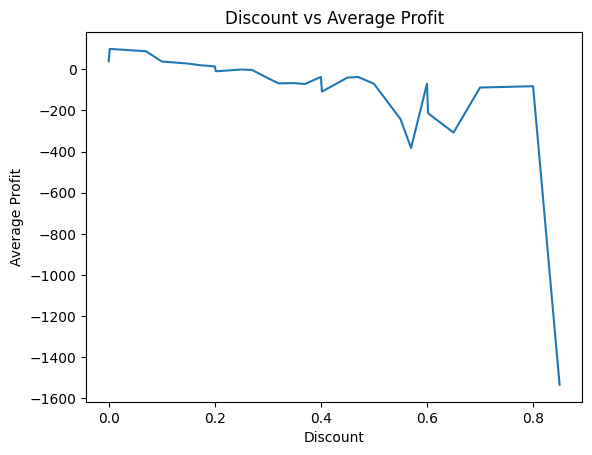

In [36]:
discount_analysis = df.groupby('discount')['profit'].mean()

discount_analysis.plot()

plt.title("Discount vs Average Profit")

plt.xlabel("Discount")

plt.ylabel("Average Profit")

plt.show()

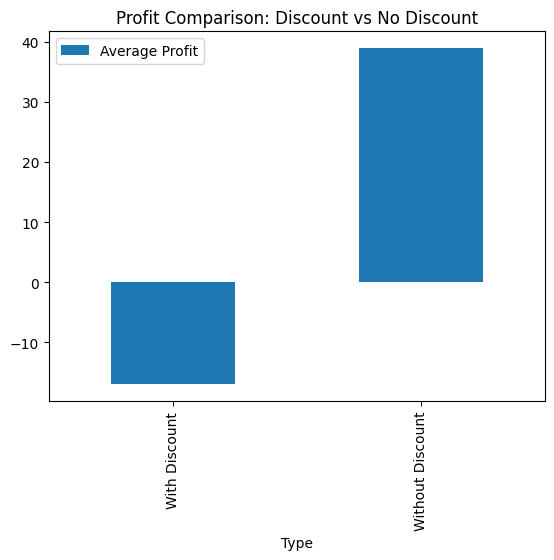

In [37]:
discount_data = {
    'Type': ['With Discount', 'Without Discount'],
    'Average Profit': [profit_discount, profit_no_discount]
}

discount_df = pd.DataFrame(discount_data)

discount_df.plot(x='Type', y='Average Profit', kind='bar')

plt.title("Profit Comparison: Discount vs No Discount")

plt.show()

In [38]:
# Key Business Metrics

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df.shape[0]
avg_discount = df['discount'].mean()
avg_shipping_cost = df['shipping_cost'].mean()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Average Discount:", avg_discount)
print("Average Shipping Cost:", avg_shipping_cost)

Total Sales: 7835128.0
Total Profit: 714730.17478
Total Orders: 48660
Average Discount: 0.14572157829839702
Average Shipping Cost: 17.593780106863957


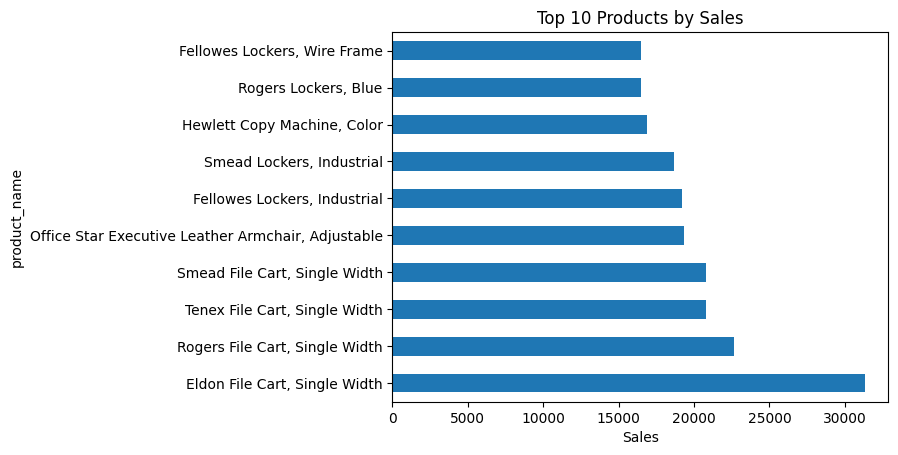

In [39]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales")

plt.show()

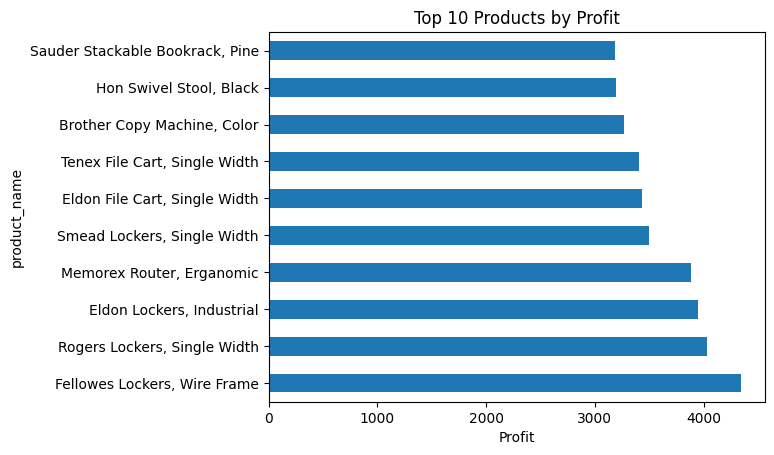

In [40]:
top_profit_products = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

top_profit_products.plot(kind='barh')

plt.title("Top 10 Products by Profit")

plt.xlabel("Profit")

plt.show()

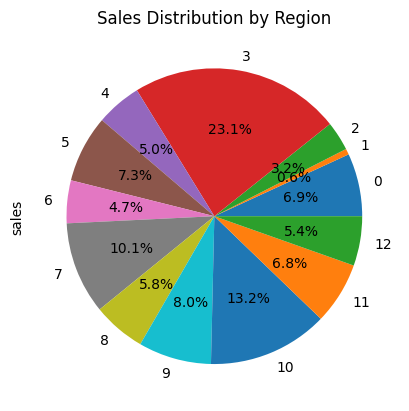

In [41]:
region_sales = df.groupby('region')['sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales Distribution by Region")

plt.show()

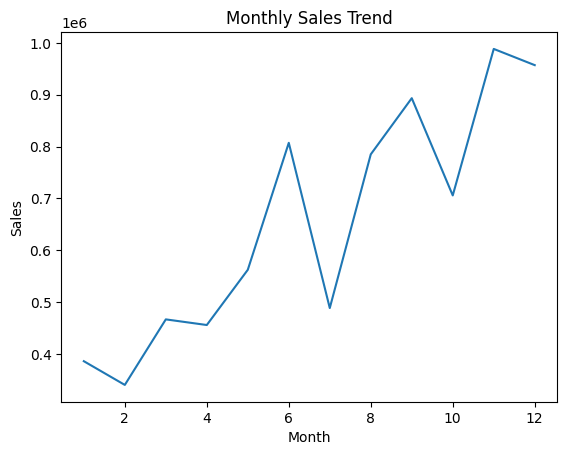

In [42]:
monthly_sales = df.groupby('order_month')['sales'].sum()

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [45]:
powerbi_df = df.copy()

powerbi_df['profit_label'] = powerbi_df['profit'].apply(lambda x: "Profit" if x > 0 else "Loss")

powerbi_df['order_month_name'] = powerbi_df['order_date'].dt.month_name()

powerbi_df['sales_category'] = pd.cut(
    powerbi_df['sales'],
    bins=[0,100,500,1000,5000,10000],
    labels=['Low','Medium','High','Very High','Premium']
)
powerbi_df.to_csv("powerbi_superstore_dataset.csv", index=False)

print("File saved successfully")

File saved successfully
